# Assignment 1 — RLHF Pipeline: Supervised Fine-Tuning (SFT)


**Models:**
- Model : `gpt2` 


## Environment Setup

In [56]:
# Install required packages
# Run this cell once, then restart the kernel
# %pip install transformers datasets accelerate torch --quiet

In [57]:
import os
import torch

# ── Device Configuration ──────────────────────────────────────────────────────
# Automatically selects the best available device:
#   - 'cuda'  → Google Colab / NVIDIA GPU
#   - 'mps'   → Apple Silicon (M1/M2/M3/M4)
#   - 'cpu'   → Fallback

if torch.cuda.is_available():
    DEVICE = 'cuda'
elif torch.backends.mps.is_available():
    DEVICE = 'mps'
    # Allow MPS to fall back to CPU for unsupported ops instead of crashing
    os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"
else:
    DEVICE = 'cpu'

print(f"Using device: {DEVICE}")
print(f"PyTorch version: {torch.__version__}")

Using device: mps
PyTorch version: 2.7.0


## Imports

In [59]:
from transformers import AutoTokenizer
import matplotlib.pyplot as plt
from transformers import AutoTokenizer
from datasets import Dataset

tokenizer = AutoTokenizer.from_pretrained("gpt2")

In [60]:
# ── Memory-Safe Hyperparameters ───────────────────────────────────────────────
# These settings are tuned for 16GB unified memory (Apple M4).

MAX_SEQ_LENGTH = 512          # Caps token length — critical for memory


## 1. Load and Explore the oasst1 Dataset

**OpenAssistant/oasst1** is a human-annotated conversational dataset with:
- 84437 training messages and 4401 validation messages
- Each message has a `role` field: either `'prompter'` (human) or `'assistant'` (model)
- Messages are organised into conversation trees with quality rankings

### Conversation Tree Example

- **[Prompter]**: *"Explain quantum computing"*  *(root message)*
  - **[Assistant] Response A** — rank = **0**  *(best)*
  - **[Assistant] Response B** — rank = **1**
  - **[Assistant] Response C** — rank = **2** *(worst)*
    - **[Prompter]**: *"Can you simplify that?"*  *(follow-up)*
      - **[Assistant] Reply X** — rank = **0**
      - **[Assistant] Reply Y** — rank = **1**
        
For SFT, we extract only the **assistant** responses (what we want the model to learn to generate).

In [62]:
# Load the oasst1 dataset from HuggingFace Hub
print("Loading OpenAssistant/oasst1 dataset...")
raw_dataset = load_dataset("OpenAssistant/oasst1")
print(raw_dataset)

Loading OpenAssistant/oasst1 dataset...
DatasetDict({
    train: Dataset({
        features: ['message_id', 'parent_id', 'user_id', 'created_date', 'text', 'role', 'lang', 'review_count', 'review_result', 'deleted', 'rank', 'synthetic', 'model_name', 'detoxify', 'message_tree_id', 'tree_state', 'emojis', 'labels'],
        num_rows: 84437
    })
    validation: Dataset({
        features: ['message_id', 'parent_id', 'user_id', 'created_date', 'text', 'role', 'lang', 'review_count', 'review_result', 'deleted', 'rank', 'synthetic', 'model_name', 'detoxify', 'message_tree_id', 'tree_state', 'emojis', 'labels'],
        num_rows: 4401
    })
})


In [63]:
# print some sample data for visualization
cols = ["message_id","parent_id","role","text","rank"]   

for i in range(0,10):
    sample = raw_dataset['train'][i]

    filtered_sample = {k: v for k, v in sample.items() if k in cols}

    print(json.dumps(filtered_sample, indent=4))
    print("=" * 60)

{
    "message_id": "6ab24d72-0181-4594-a9cd-deaf170242fb",
    "parent_id": null,
    "text": "Can you write a short introduction about the relevance of the term \"monopsony\" in economics? Please use examples related to potential monopsonies in the labour market and cite relevant research.",
    "role": "prompter",
    "rank": null
}
{
    "message_id": "c8e83833-ecbc-44fe-b6db-735228c25a1c",
    "parent_id": "6ab24d72-0181-4594-a9cd-deaf170242fb",
    "text": "\"Monopsony\" refers to a market structure where there is only one buyer for a particular good or service. In economics, this term is particularly relevant in the labor market, where a monopsony employer has significant power over the wages and working conditions of their employees. The presence of a monopsony can result in lower wages and reduced employment opportunities for workers, as the employer has little incentive to increase wages or provide better working conditions.\n\nRecent research has identified potential monopso

## 2. Preprocess the Dataset
We format each example as a prompt-response pair:
```
{H:prompt + \nA: + response+EOS}
```

Filtering criteria:
1. **English only** (`lang == 'en'`) — GPT-2 is an English model
2. **Assistant role only** — we want the model to learn response generation
3. **Top-ranked messages** (`rank == 0`) — highest quality responses only

In [65]:
def preprocess_oasst1(dataset):
    """
    Filter and format oasst1 messages for SFT.
    
    We keep only English, top-ranked assistant messages.
    Each example is formatted as a <human>/<assistant> exchange.
    
    Args:
        dataset: A HuggingFace dataset split (train or validation)
    
    Returns:
        List of formatted prompt strings ready for tokenization
    """
    texts = []
    
    # Build a lookup: message_id → message content
    # This lets us find the parent (prompter) message for each assistant reply
    id_to_msg = {msg['message_id']: msg for msg in dataset}
    
    for msg in dataset:
        # Only process English, top-ranked assistant messages
        if msg['role'] != 'assistant':
            continue
        if msg['lang'] != 'en':
            continue
        if msg['rank'] != 0:  # rank=0 means highest quality
            continue
        
        # Find the parent prompter message (the human turn)
        parent_id = msg.get('parent_id')
        if parent_id is None or parent_id not in id_to_msg:
            continue
        
        parent_msg = id_to_msg[parent_id]
        if parent_msg['role'] != 'prompter':
            continue
        
        # Format as a conversational prompt-response pair
        prompt = parent_msg['text'].strip()
        response = msg['text'].strip()
        
        # Skip very short or empty texts
        if len(prompt) < 10 or len(response) < 10:
            continue
        
        formatted = f"H: {prompt}\nA: {response}{tokenizer.eos_token}"
        
        texts.append(formatted)
    
    return texts

# Apply preprocessing to train and validation splits
print("Preprocessing training data...")
oasst_train_filtered = preprocess_oasst1(raw_dataset['train'])

print("Preprocessing validation data...")
oasst_val_filtered = preprocess_oasst1(raw_dataset['validation'])

print(f"\nTraining examples  : {len(oasst_train_filtered)}")
print(f"Validation examples: {len(oasst_val_filtered)}")

Preprocessing training data...
Preprocessing validation data...

Training examples  : 7746
Validation examples: 414


In [66]:
# Inspect a few formatted examples
print("=" * 60)
for i, text in enumerate(oasst_train_filtered[:10]):
    print(text)
    print("=" * 60)

H: Can you write a short introduction about the relevance of the term "monopsony" in economics? Please use examples related to potential monopsonies in the labour market and cite relevant research.
A: "Monopsony" refers to a market structure where there is only one buyer for a particular good or service. In economics, this term is particularly relevant in the labor market, where a monopsony employer has significant power over the wages and working conditions of their employees. The presence of a monopsony can result in lower wages and reduced employment opportunities for workers, as the employer has little incentive to increase wages or provide better working conditions.

Recent research has identified potential monopsonies in industries such as retail and fast food, where a few large companies control a significant portion of the market (Bivens & Mishel, 2013). In these industries, workers often face low wages, limited benefits, and reduced bargaining power, leading to a situation whe

Min length : 44
Max length : 11439
Mean length: 1128


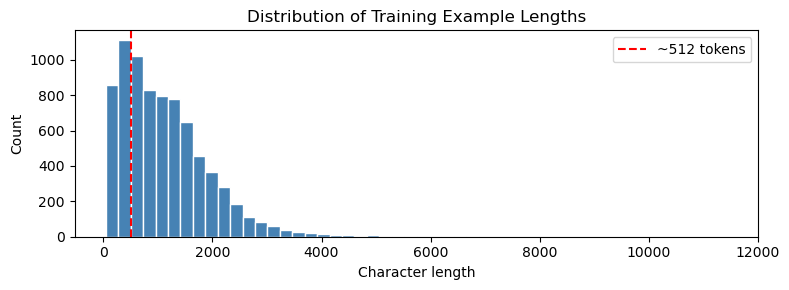

In [67]:
# Analyse text length distribution (in characters)
lengths = [len(t) for t in oasst_train_filtered]
print(f"Min length : {min(lengths)}")
print(f"Max length : {max(lengths)}")
print(f"Mean length: {sum(lengths)/len(lengths):.0f}")

plt.figure(figsize=(8, 3))
plt.hist(lengths, bins=50, color='steelblue', edgecolor='white')
plt.axvline(MAX_SEQ_LENGTH, color='red', linestyle='--', label=f'~{MAX_SEQ_LENGTH} tokens')
plt.xlabel('Character length')
plt.ylabel('Count')
plt.title('Distribution of Training Example Lengths')
plt.legend()
plt.tight_layout()
plt.show()

## 3. Tokenize the Dataset

We convert the raw text into token IDs that the models can consume.
Key decisions:
- `max_length=512`: Caps sequence length to limit memory usage
- `truncation=True`: Silently truncates anything over 128 tokens
- `padding='max_length'`: Pads short sequences to 128 for uniform batch sizes
- GPT-2 has no pad token, so we reuse the EOS token as padding

In [69]:
def build_tokenized_dataset(model_name, train_texts, val_texts):
    """
    Load a tokenizer and tokenize the train/val text lists.
    
    Args:
        model_name  : HuggingFace model identifier (e.g. 'gpt2')
        train_texts : List of formatted training strings
        val_texts   : List of formatted validation strings
    
    Returns:
        tokenizer, tokenized_train, tokenized_val
    """
    print(f"Loading tokenizer: {model_name}")
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    
    # GPT-2 has no dedicated pad token — reuse EOS token
    # The attention_mask will ensure padding positions are ignored in the loss
    tokenizer.pad_token = tokenizer.eos_token
    
    def tokenize_fn(batch):
        """Tokenize a batch of texts with padding and truncation."""
        return tokenizer(
            batch['text'],
            max_length=MAX_SEQ_LENGTH,
            truncation=True,
            padding='max_length'
        )
    
    # Wrap raw text lists in HuggingFace Dataset objects for efficient mapping
    train_ds = Dataset.from_dict({'text': train_texts})
    val_ds   = Dataset.from_dict({'text': val_texts})
    
    # Tokenize in batches; remove the raw text column after encoding
    tok_train = train_ds.map(tokenize_fn, batched=True, batch_size=512,
                             remove_columns=['text'])
    tok_val   = val_ds.map(tokenize_fn,   batched=True, batch_size=512,
                           remove_columns=['text'])
    
    # Convert to PyTorch tensors
    tok_train.set_format(type='torch')
    tok_val.set_format(type='torch')
    
    print(f"  Train: {len(tok_train)} examples")
    print(f"  Val  : {len(tok_val)} examples")
    
    return tokenizer, tok_train, tok_val


# Build tokenized datasets for GPT-2
# (distilgpt2 shares the same tokenizer as gpt2, so we can reuse these datasets)
tokenizer, tokenized_ds_train, tokenized_ds_val = build_tokenized_dataset('gpt2', oasst_train_filtered, oasst_val_filtered)

# Inspect a tokenized example
print("\nTokenized example keys:", list(tokenized_ds_train[0].keys()))
print("input_ids shape:", tokenized_ds_train[0]['input_ids'].shape)

print("\n Tokenized Data at index 0 :", tokenized_ds_train[0])

Loading tokenizer: gpt2


Map:   0%|          | 0/7746 [00:00<?, ? examples/s]

Map:   0%|          | 0/414 [00:00<?, ? examples/s]

  Train: 7746 examples
  Val  : 414 examples

Tokenized example keys: ['input_ids', 'attention_mask']
input_ids shape: torch.Size([512])

 Tokenized Data at index 0 : {'input_ids': tensor([   39,    25,  1680,   345,  3551,   257,  1790,  9793,   546,   262,
        23082,   286,   262,  3381,   366,  2144,   404,  1559,    88,     1,
          287, 12446,    30,  4222,   779,  6096,  3519,   284,  2785, 15848,
         1559,   444,   287,   262, 10515,  1910,   290, 21729,  5981,  2267,
           13,   198,    32,    25,   366,  9069,   404,  1559,    88,     1,
        10229,   284,   257,  1910,  4645,   810,   612,   318,   691,   530,
        17872,   329,   257,  1948,   922,   393,  2139,    13,   554, 12446,
           11,   428,  3381,   318,  3573,  5981,   287,   262,  4827,  1910,
           11,   810,   257, 15848,  1559,    88,  9749,   468,  2383,  1176,
          625,   262,  9400,   290,  1762,  3403,   286,   511,  4409,    13,
          383,  4931,   286,   257, 158